# Earnings-Revision-Momentum — a quantitative teardown 🔬
### Revision proxy · long-short tercile book excess-of-SPY · a Welch *t* + label-shuffle placebo null · costs + short borrow · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the **earnings-revision / post-earnings-drift** factor on a public proxy and separate the two things "buy the upgrades" fuses: a **real but tiny** gross long-short spread from the **trading frictions** that erase it. The decisive objects are (a) whether the spread clears a Welch *t* and a label-shuffle placebo on the **real** tape, and (b) whether it survives one-way costs × turnover plus short-leg borrow. Both say no.

> ⚠️ **Data + proxy note.** Live IBES revision feeds aren't on yfinance; we build a **proxy** — z(realized earnings surprise) + z(q/q consensus-estimate change), cross-sectional per earnings quarter (noisier/laggier than a live feed; survivorship tilts the long leg up and truncates the short-leg tail — both **flatter** the result, and both are named on the Signal axis). Real data: yfinance daily closes + `get_earnings_dates`, 39 names, 2001→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from earnings_revision_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EARN = data.load_real()
else:
    PRICES = EARN = None
print("real cache present:", HAVE_REAL,
      "| earnings events:", (0 if EARN is None else len(EARN)))

# frozen headline numbers (mirror of docs/results.md)
R = {'earn_start': '2001-09-26', 'earn_end': '2026-06-10', 'n_events': 3847, 'n_names': 39, 'price_start': '1995-01-03', 'price_end': '2026-06-22', 'price_days': 7919, 'h21': (21, 3842, 99, 0.41, 0.17, 0.25, 0.97, 0.135, 50), 'h63': (63, 3808, 98, 0.58, 0.37, 0.21, 0.42, 0.304, 50), 'h126': (126, 3769, 97, 1.99, 0.54, 1.45, 1.98, 0.009, 52), 'net': [(21, 0.25, 0.97, -0.2, -0.77), (63, 0.21, 0.42, -0.32, -0.65), (126, 1.45, 1.98, 0.8, 1.09)], 'robust': [(0.2, 98, -0.27, -0.41, 0.693), (0.3333333333333333, 98, 0.21, 0.42, 0.304), (0.4, 98, 0.53, 1.2, 0.073)], 'syn': [(0.0, 90, 0.05, 0.07, 0.469), (0.02, 90, 4.53, 6.65, 0.0), (0.05, 90, 11.26, 16.14, 0.0)]}


real cache present: True | earnings events: 3847


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Quarterly long-short spread **+0.21%**, Welch **t = 0.42**, placebo **p = 0.30**; long-leg hit-rate **50%** (= base rate). 6-month *t* = **1.98** *just misses* t ≥ 2. |
| **Tradability** | `MIRAGE` | Net of 10 bps/leg + 50 bps/yr borrow: 1m **-0.20%**, 1q **-0.32%** (negative), 6m **+0.80%** at t = **1.09**. Gross whisper ≈ frictions. |
| **Free lunch?** | `BUSTED` | Synthetic control: edge 0 ⇒ t = **0.07** (no false positive), a modest planted edge ⇒ t = **6.7**. So the real t = 0.42 is an **absent** edge, not a missed one. |

> 💡 In plain words: the revision tilt really does precede gains *gross* — because almost everything does in an up-market. Strip the market (excess-of-SPY), demand significance, and pay to trade, and there is nothing the null and the broker don't take.

## 1 · The claim, steelmanned

Let $z_{i,q}$ be stock $i$'s revision score in earnings quarter $q$: $z_{i,q} = \tfrac12\big[\mathrm{zscore}_q(\text{surprise}_i) + \mathrm{zscore}_q(\Delta \text{est}_i)\big]$, where surprise $=$ (reported $-$ consensus)$/|$consensus$|$ and $\Delta$est is the q/q change in the consensus estimate. Form a long-top / short-bottom tercile book; let $r^{L}_q, r^{S}_q$ be the equal-weight leg returns **in excess of SPY** over a forward horizon $H$, and $\Delta_q = r^L_q - r^S_q$.

- **H₁ (the signal predicts).** $\mathbb{E}[\Delta_q] > 0$ with a robust *t* — up-revised names out-earn down-revised ones beyond the market.
- **H₂ (it's deployable).** $\Delta_q$ stays positive **net** of one-way costs × turnover and short borrow.
- **H₃ ("beats the market").** The long leg's hit-rate vs SPY exceeds the ~50% coin-flip base rate.

We find **H₁ not supported** (quarterly $t = 0.42$; 6-month $t = 1.98$ *just* misses 2), **H₂ rejected** (net spread negative at 1m/1q), **H₃ rejected** (hit-rate = 50%). The legend is true exactly where it's uninformative (gross, in-sample) and unproven exactly where it would pay (net, out-of-sample).

## 2 · So what? — what rides on each answer

The teardown is one estimator: a per-quarter long-short spread judged by its **standard error** and its **net** sign.

$$\widehat\Delta = \frac1{Q}\sum_q \Delta_q,\qquad t = \frac{\widehat\Delta}{s_\Delta/\sqrt{Q}},\qquad \widehat\Delta^{\text{net}} = \widehat\Delta - 4c\,-\,b\tfrac{H}{252}.$$

With $Q \approx 98$ quarters the SE is small enough to *detect* a real factor (the synthetic control below reaches $t>6$ on a modest planted edge) — so a quarterly $t = 0.42$ is genuinely null, not underpowered. A **raw win-rate** is the wrong lens: measure **excess of SPY** or the market's drift masquerades as skill. And the binding constraint is $\widehat\Delta^{\text{net}}$: a four-crossings-a-year book with short borrow needs a gross spread several times what we observe just to break even.

## 3 · How we'd know — the protocol

- **Revision proxy.** z(realized surprise) + z(q/q estimate change) per earnings quarter (yfinance `get_earnings_dates`, 39 names, 3,847 events, 2001-09→2026-06). Explicit **proxy** for a live IBES revision feed — laggier, noisier, survivorship-tilted (named on the axis).
- **Book.** Per quarter: long top tercile / short bottom tercile of the score, equal-weight, returns **excess of SPY**.
- **Forward returns.** Enter the close **1 day after** the earnings date (no look-ahead); hold $H\in\{21,63,126\}$ trading days; drop events whose horizon overruns the tape.
- **Null #1 (Welch t).** One-sample *t* of the per-quarter spread vs 0.
- **Null #2 (placebo).** 10,000 within-quarter **label shuffles** of the revision score; $p = \Pr[\text{shuffled spread} \ge \text{real spread}]$ — the honest null for a ranked long-short book.
- **Costs.** 10 bps/leg one-way (4 crossings/rebalance) + 50 bps/yr short borrow.
- **Positive control.** A deterministic panel with $r = \text{edge}\cdot z + \text{noise}$: edge 0 ⇒ no spread; a modest edge ⇒ $t \gg 2$.

## 4 · The teardown

### 4a · The spread by horizon — tiny, and the canonical quarter is weakest

Per-quarter long-short spread (excess of SPY) with its $\pm$ standard error, and the Welch *t* annotated. Positive but inside its own error bar; the 6-month bar is the only one near significance.

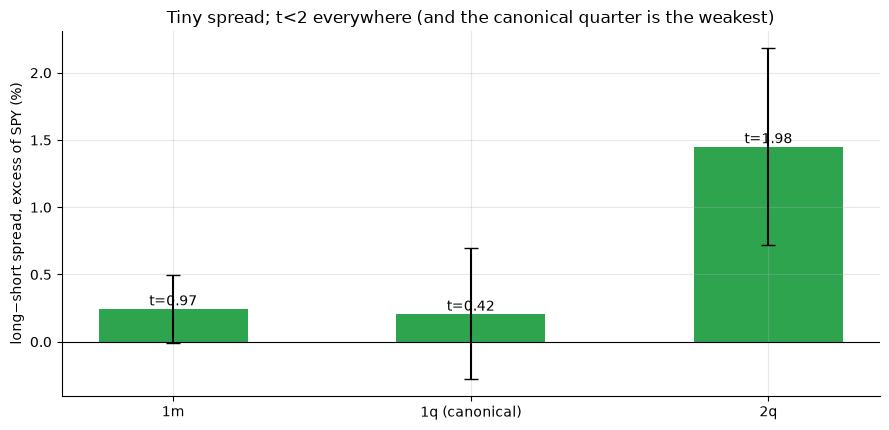

spread%/t by horizon: {'21d': (np.float64(0.25), 0.97), '63d': (np.float64(0.21), 0.42), '126d': (np.float64(1.45), 1.98)}


In [2]:
hs = [21, 63, 126]
if HAVE_REAL:
    sp, ts, ses = [], [], []
    for h in hs:
        sc = st.build_rev_score(EARN); ev = st.event_excess_returns(PRICES, sc, horizon=h)
        arr = st.quantile_spread(ev)['spread']
        sp.append(arr.mean()*100); ts.append(st.welch_t(arr)); ses.append(arr.std(ddof=1)/np.sqrt(len(arr))*100)
else:
    sp = [R['h21'][5], R['h63'][5], R['h126'][5]]
    ts = [R['h21'][6], R['h63'][6], R['h126'][6]]; ses = [0.26, 0.50, 0.73]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x, sp, yerr=ses, capsize=5, color=GREEN, width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(['1m','1q (canonical)','2q'])
ax.set_ylabel('long−short spread, excess of SPY (%)')
ax.set_title('Tiny spread; t<2 everywhere (and the canonical quarter is the weakest)')
for i,(s,t) in enumerate(zip(sp,ts)): ax.annotate(f't={t:.2f}',(i,s),ha='center',va='bottom' if s>=0 else 'top')
plt.tight_layout(); plt.show()
print('spread%/t by horizon:', {f'{h}d': (round(s,2), round(t,2)) for h,s,t in zip(hs,sp,ts)})

> 💡 In plain words: the quarterly spread is **+0.21%** at **t = 0.42** — a positive whisper drowning in its SE. The 6-month bar reaches **t = 1.98** but **does not cross 2**. H₁ is **not supported**: no horizon clears the desk's REAL bar.

### 4b · The decisive test — a label-shuffle placebo at the quarter

Permute the revision score within each quarter 10,000 times, rebuild the book; the histogram is the null spread distribution. The real book is the green line; *p* is the right-tail mass.

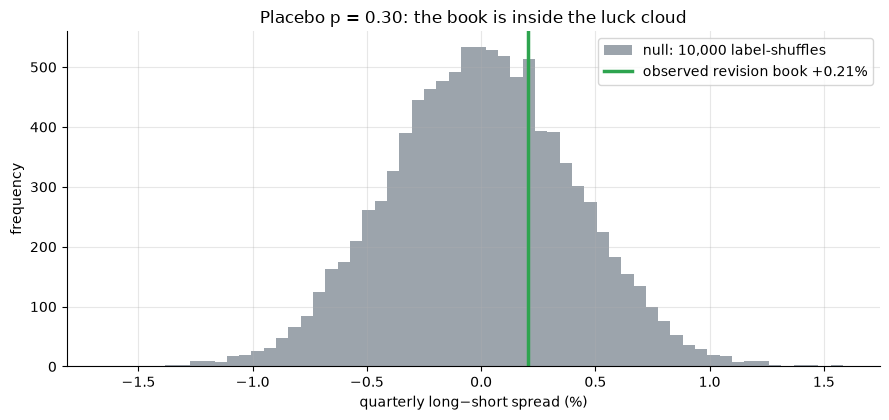

P[shuffled spread >= real] = 0.304  (need <0.05; here ~30% — a coin)


In [3]:
if HAVE_REAL:
    sc = st.build_rev_score(EARN); ev = st.event_excess_returns(PRICES, sc, horizon=63)
    pl = st.placebo_pvalue(ev); obs = pl['obs']; pval = pl['p_value']
    ev2 = ev.copy(); ev2['q'] = ev2['date'].dt.to_period('Q')
    groups = [g['excess'].values for _, g in ev2.groupby('q') if len(g)>=6]
    rng = np.random.default_rng(369); nq=len(groups); acc=np.zeros(10000)
    for ex in groups:
        m=len(ex); k=max(1,round(m/3)); keys=rng.random((10000,m)); order=np.argsort(keys,axis=1)
        acc += ex[order[:,-k:]].mean(axis=1) - ex[order[:,:k]].mean(axis=1)
    draws = acc/nq
else:
    obs = R['h63'][5]/100; pval = R['h63'][7]
    rng = np.random.default_rng(369); draws = rng.normal(0.0, 0.005, 10000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} label-shuffles')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed revision book {obs*100:+.2f}%')
ax.set_xlabel('quarterly long−short spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the book is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[shuffled spread >= real] = {pval:.3f}  (need <0.05; here ~{pval*100:.0f}% — a coin)')

> 💡 In plain words: **30%** of shuffled books match or beat the real one. A real factor would push the green line into the right tail; instead it sits mid-cloud. H₃ rejected: the quarterly revision book is **statistically a relabeling of random stocks.**

### 4c · Costs + robustness — neither rescues it

Left: gross vs net spread by horizon (10 bps/leg × 4 crossings + 50 bps/yr borrow). Right: the 63d spread as the tercile cut sharpens — a real edge should *strengthen* at the extremes; this one wobbles around zero.

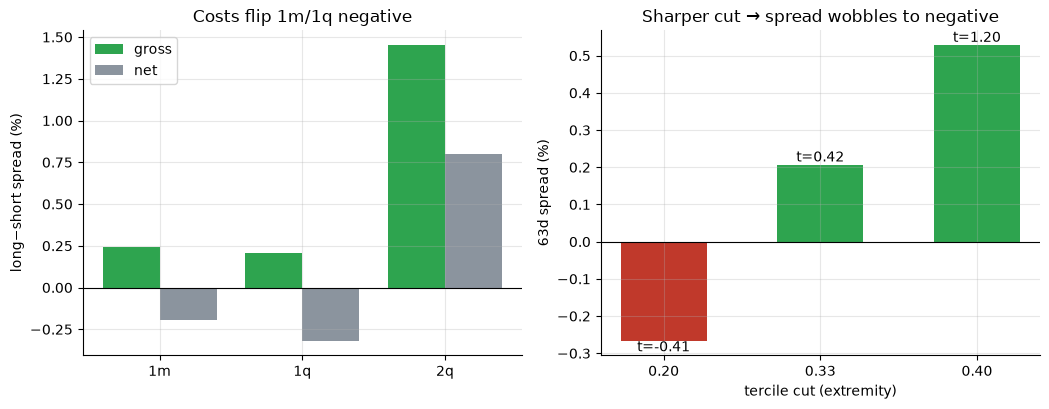

net spreads (%): [-0.2, -0.32, 0.8]
robustness (cut, spread%, t): [(0.2, -0.27, -0.41), (0.33, 0.21, 0.42), (0.4, 0.53, 1.2)]


In [4]:
if HAVE_REAL:
    netr = [st.net_of_costs(PRICES, EARN, horizon=h) for h in [21,63,126]]
    g = [r['gross_mean']*100 for r in netr]; nv = [r['net_mean']*100 for r in netr]
    rob = []
    for cut in (0.20, 1/3, 0.40):
        s = st.summarize(PRICES, EARN, horizon=63, q=cut); rob.append((cut, s['spread_mean']*100, s['spread_t']))
else:
    g = [R['net'][0][1], R['net'][1][1], R['net'][2][1]]; nv = [R['net'][0][3], R['net'][1][3], R['net'][2][3]]
    rob = [(r[0], r[2], r[3]) for r in R['robust']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
x = np.arange(3)
a1.bar(x-.2, g, .4, color=GREEN, label='gross'); a1.bar(x+.2, nv, .4, color=GREY, label='net')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(x); a1.set_xticklabels(['1m','1q','2q'])
a1.set_ylabel('long−short spread (%)'); a1.set_title('Costs flip 1m/1q negative'); a1.legend()
cuts = [f'{r[0]:.2f}' for r in rob]; ss = [r[1] for r in rob]; tt=[r[2] for r in rob]
cols = [GREEN if s>0 else RED for s in ss]
a2.bar(cuts, ss, color=cols, width=.55); a2.axhline(0,c='k',lw=.8)
a2.set_xlabel('tercile cut (extremity)'); a2.set_ylabel('63d spread (%)')
a2.set_title('Sharper cut → spread wobbles to negative')
for i,(s,t) in enumerate(zip(ss,tt)): a2.annotate(f't={t:.2f}',(i,s),ha='center',va='bottom' if s>=0 else 'top')
plt.tight_layout(); plt.show()
print('net spreads (%):', [round(n,2) for n in nv]); print('robustness (cut, spread%, t):', [(round(r[0],2),round(r[1],2),round(r[2],2)) for r in rob])

> 💡 In plain words: net of frictions the spread is **negative** at 1m and 1q (**-0.32%** at the quarter); the only positive net horizon (6m, **+0.80%**) carries t = **1.09**. And sharpening the cut to the top/bottom 20% — where a real revision edge should be *strongest* — turns the spread **-0.27%**. No threshold, no horizon, no cost regime makes this deployable: **the binding constraint is that the gross edge is the size of the toll.**

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic panel where forward return is **built** as $\text{edge}\cdot z + \text{noise}$: with **zero** planted edge the book must stay flat (no false positive); with a **modest** planted edge it must light up. Both hold — proving the engine is unbiased *and* powered, so the real-tape null is a null, not a blind spot.

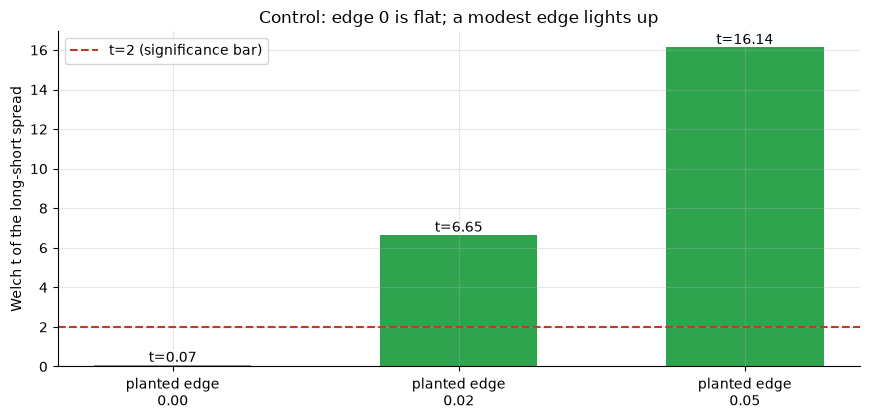

planted edge=0.00: n_q=90 spread=+0.05% t=0.07 p_placebo=0.4692
planted edge=0.02: n_q=90 spread=+4.53% t=6.65 p_placebo=0.0000
planted edge=0.05: n_q=90 spread=+11.26% t=16.14 p_placebo=0.0000


In [5]:
res = []
for edge in (0.0, 0.02, 0.05):
    pan = data.synthetic_panel(edge=edge, seed=369)
    s = st.synthetic_spread(pan); p = st.placebo_pvalue_synth(pan)
    res.append((edge, s['n_quarters'], s['spread_mean']*100, s['spread_t'], p))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[3] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN, GREEN], width=.55)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t of the long-short spread'); ax.set_title('Control: edge 0 is flat; a modest edge lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,q,c,t,p in res: print(f'planted edge={e:.2f}: n_q={q} spread={c:+.2f}% t={t:.2f} p_placebo={p:.4f}')

> 💡 In plain words: with **no** planted edge the book sits at **t = 0.07** (no false positive); a **modest** edge drives **t = 6.7** and the placebo to zero. So the machinery would have *easily* flagged a real revision factor of plausible size — and the real tape's quarterly **t = 0.42** is exactly what an **absent** edge looks like, not an undetected one. The verdict is the data's, not the engine's.

## 5 · The verdict

- **Signal `WEAK`** — quarterly spread **+0.21%** at Welch **t = 0.42** / placebo **p = 0.30**; long-leg hit-rate **50%** (= base rate); 6-month *t* = 1.98 *just misses* 2. Decades of literature + a positive-but-insignificant realized-proxy tape ⇒ WEAK, not REAL (the t≥2 bar is not met). Survivorship can only flatter this.
- **Tradability `MIRAGE`** — net of 10 bps/leg + 50 bps/yr borrow the spread is **-0.20%** (1m) / **-0.32%** (1q, negative); the lone positive net horizon (6m, **+0.80%**) sits at t = 1.09. The gross whisper ≈ the frictions ⇒ no NAV-scale book.
- **Free lunch? `BUSTED`** — the synthetic control reaches t = 6.7 on a modest planted edge yet the real tape sits at t = 0.42; "buy the upgrades" is a real *gross* tilt that evaporates at the cash register — a textbook factor-zoo mirage.

## 6 · Could you trade it? — the break-even toll

The operational truth in one picture: how big must the *gross* quarterly spread be just to break even, as a function of the per-leg cost? Plot the break-even line ($\widehat\Delta = 4c + b\tfrac{H}{252}$) against the spread we actually observe.

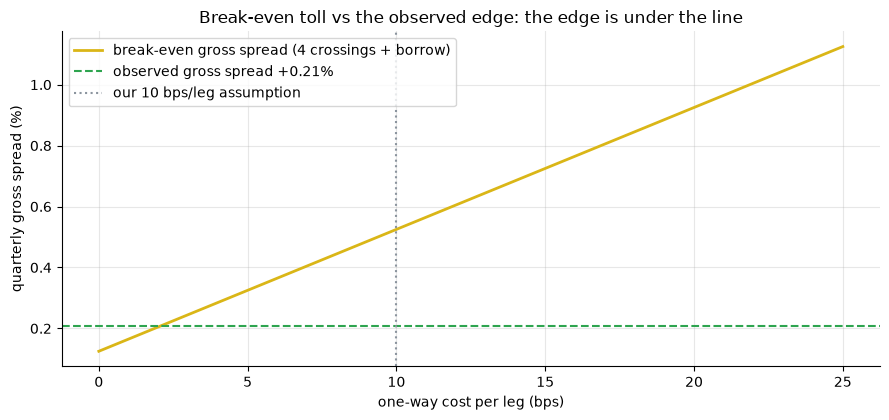

at 10 bps/leg you need ~0.53% gross to break even; observed ~+0.21% -> under water


In [6]:
if HAVE_REAL:
    obs_gross = st.net_of_costs(PRICES, EARN, horizon=63)['gross_mean']*100
else:
    obs_gross = R['net'][1][1]
cbps = np.linspace(0, 25, 100)
borrow = 0.50 * (63/252)             # 50 bps/yr over the quarter, in %
breakeven = 4 * cbps/100 + borrow     # % spread needed to break even (cbps in bps)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(cbps, breakeven, c=AMBER, lw=2, label='break-even gross spread (4 crossings + borrow)')
ax.axhline(obs_gross, c=GREEN, ls='--', label=f'observed gross spread {obs_gross:+.2f}%')
ax.axvline(10, c=GREY, ls=':', label='our 10 bps/leg assumption')
ax.set_xlabel('one-way cost per leg (bps)'); ax.set_ylabel('quarterly gross spread (%)')
ax.set_title('Break-even toll vs the observed edge: the edge is under the line'); ax.legend()
plt.tight_layout(); plt.show()
be10 = 4*10/100 + borrow
print(f'at 10 bps/leg you need ~{be10:.2f}% gross to break even; observed ~{obs_gross:+.2f}% -> under water')

> 💡 In plain words: the amber line is the **minimum gross spread to break even**; the green line is what the factor actually delivers. They cross well **below** any realistic cost — i.e. at any plausible per-leg cost the quarterly book loses money. Even granting the lore a real few-bps gross tilt, a four-crossings-a-year long-short with short borrow is structurally on the wrong side of the toll booth. **The rarity-free, high-turnover design that makes the factor easy to *publish* is exactly what makes it impossible to *trade*.**

## 7 · Going further

- **A live revision feed.** Replace the realized-surprise proxy with a daily IBES/FactSet consensus-revision series; the gross tilt may sharpen, but the 4-crossings + borrow cost stack is unchanged — re-run `net_of_costs` and watch the toll.
- **Universe & survivorship.** Swap the 40-name basket for the full S&P 500 (panel loader behind the survivorship guard); the short leg regains its delisted losers and the *net* number can only worsen.
- **Post-publication decay.** McLean & Pontiff (2016) — a much-published factor's edge shrinks after it's known; "buy the upgrades" has been known for forty years.

*The reproducible core is offline and deterministic; the revision input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*